In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
X, y = make_blobs(n_samples=500, centers=4, random_state=42, cluster_std=1.5)

In [4]:
X.shape, y.shape

((500, 2), (500,))

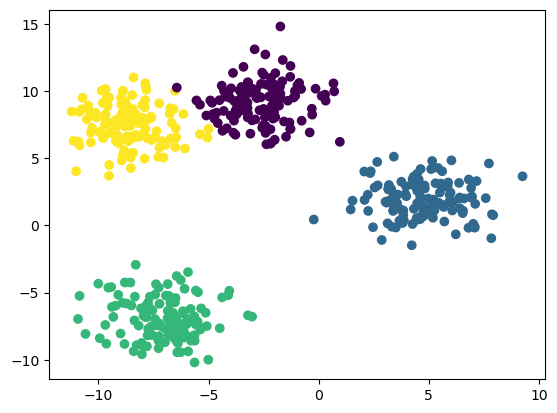

In [9]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [10]:
from sklearn.cluster import KMeans

In [20]:
model = KMeans(4)

In [21]:
model.fit(X)

KMeans(n_clusters=4)

In [22]:
pred_labels = model.labels_

In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
from sklearn.metrics import accuracy_score
import numpy as np


# Create contingency table
cm = confusion_matrix(y, pred_labels)

# Use Hungarian algorithm to map clusters to correct labels
# The Hungarian algorithm finds the optimal one-to-one mapping between K-means clusters and true labels.
# this is needed cause the y in this dataset to check can have different mapping for 1,2,0
row_ind, col_ind = linear_sum_assignment(-cm)

# Create a mapping from kmeans labels → true labels
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Apply mapping to predictions
mapped_preds = np.array([mapping[label] for label in pred_labels])

# Accuracy
acc = accuracy_score(y, mapped_preds)

print("K-Means accuracy:", acc)


K-Means accuracy: 0.994


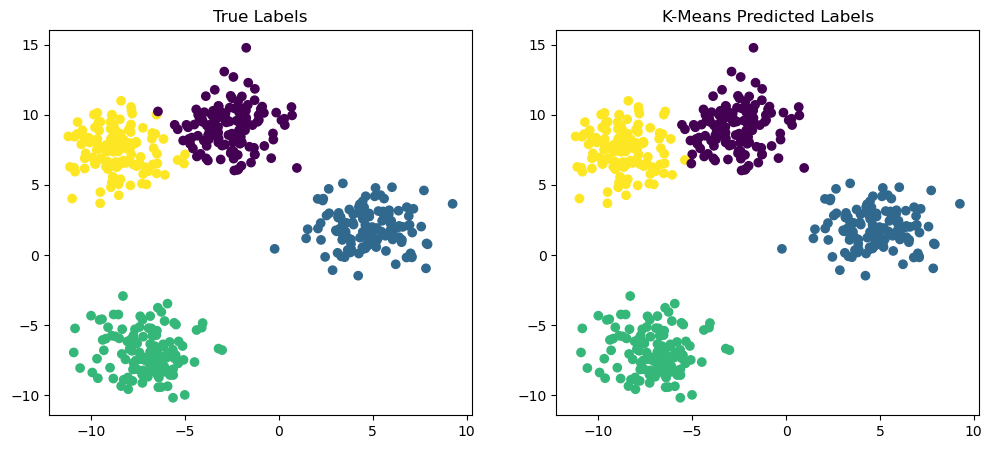

In [24]:
plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
plt.title("True Labels")
plt.scatter(X[:,0], X[:,1], c=y)

# K-Means labels (after mapping)
plt.subplot(1,2,2)
plt.title("K-Means Predicted Labels")
plt.scatter(X[:,0], X[:,1], c=mapped_preds)

plt.show()
